# K-Moda MMM · Notebook 2: Data Understanding

Análisis exploratorio del dataset maestro (`etl.csv`). Objetivo: entender las propiedades
estadísticas del target y las variables de medios **antes** de modelar, y verificar que
los datos soportan las decisiones de la pipeline.

| Pregunta | Responde |
|---|---|
| ¿Cómo se distribuyen las ventas? | §1 — Target |
| ¿Hay estacionalidad? | §1 — Estacionalidad |
| ¿Qué canal domina el presupuesto? | §2 — Medios |
| ¿Los canales co-varían con ventas? | §2 — Correlaciones |
| ¿Los eventos generan uplift real? | §3 — Calendario |
| ¿Hay memoria temporal que justifique adstock? | §4 — ACF |

**Pipeline:** ETL → **Data Understanding** → Data Preparation → Modeling → Evaluation

In [1]:
import warnings; warnings.filterwarnings("ignore")
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
from statsmodels.tsa.stattools import acf, pacf

VERSION   = 1
WAREHOUSE = os.path.join("data", "warehouse", f"version{VERSION}")
DATE_COL  = "semana_inicio"

# ── K-Moda brand palette ─────────────────────────────────────────────────────
KM_GOLD      = "#C8A96E"
KM_GOLD_DARK = "#8B6914"
KM_CHARCOAL  = "#2D2D2D"
KM_CREAM     = "#F7F4EF"
KM_GRAY      = "#9E9893"
KM_IVORY     = "#EDE8DC"
KM_CHANNELS  = ["#C8A96E", "#8B6914", "#2D2D2D", "#9E9893",
                 "#D4C4A8", "#6B5B3E", "#B8A88A", "#5C4A2A"]

plt.rcParams.update({
    "figure.facecolor":  KM_CREAM,
    "axes.facecolor":    KM_CREAM,
    "axes.edgecolor":    KM_GRAY,
    "axes.labelcolor":   KM_CHARCOAL,
    "axes.titlecolor":   KM_CHARCOAL,
    "axes.titlesize":    12,
    "axes.titlepad":     12,
    "axes.labelsize":    10,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.color":        KM_GRAY,
    "grid.alpha":        0.18,
    "grid.linestyle":    "-",
    "grid.linewidth":    0.5,
    "xtick.color":       KM_GRAY,
    "ytick.color":       KM_GRAY,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
    "legend.fontsize":   9,
    "legend.framealpha": 0.7,
    "legend.edgecolor":  KM_GRAY,
    "figure.figsize":    (14, 4.5),
    "figure.dpi":        130,
    "savefig.facecolor": KM_CREAM,
    "savefig.bbox":      "tight",
})
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", "{:,.2f}".format)
print(f"K-Moda MMM · Data Understanding · VERSION={VERSION}")

K-Moda MMM · Data Understanding · VERSION=1


## 1. Target: ventas semanales nacionales

In [2]:
df = (
    pd.read_csv(os.path.join(WAREHOUSE, "etl.csv"), parse_dates=[DATE_COL])
    .sort_values(DATE_COL)
    .reset_index(drop=True)
)

INV_COLS = ["inv_paid_search", "inv_social_paid", "inv_video_online", "inv_display",
            "inv_email_crm",   "inv_radio_local", "inv_exterior",     "inv_prensa"]
FLAG_COLS = ["black_friday_flag", "rebajas_flag", "navidad_flag",
             "semana_santa_flag", "payday_flag",
             "vacaciones_escolares_flag", "incidencia_ecommerce_flag"]

eur = mticker.FuncFormatter(lambda x, _: f"€{x/1e6:.1f}M")

print(f"Master: {df.shape[0]} semanas × {df.shape[1]} columnas")
print(f"Rango: {df[DATE_COL].min().date()} → {df[DATE_COL].max().date()}")
print(f"\nTarget  — media: €{df['venta_neta_total_eur'].mean()/1e6:.2f}M/sem "
      f"| CV: {df['venta_neta_total_eur'].std()/df['venta_neta_total_eur'].mean():.1%} "
      f"| total: €{df['venta_neta_total_eur'].sum()/1e6:.0f}M")
print(f"Inversión — media: €{df['inversion_total_eur'].mean()/1e3:.0f}k/sem "
      f"| total: €{df['inversion_total_eur'].sum()/1e6:.1f}M")

Master: 258 semanas × 50 columnas
Rango: 2020-01-06 → 2024-12-09

Target  — media: €2.94M/sem | CV: 23.8% | total: €758M
Inversión — media: €229k/sem | total: €59.0M


### Gráfica 1 · Distribución y variabilidad del target

Las ventas tienen un **CV del 24%** con dos regímenes claros: semanas ordinarias (~€2.5–3.5M)
y picos de Black Friday/Rebajas. Esta varianza es la señal que el modelo necesita para
atribuir contribuciones a los canales — si fuera menor, ElasticNet purgaría los β.

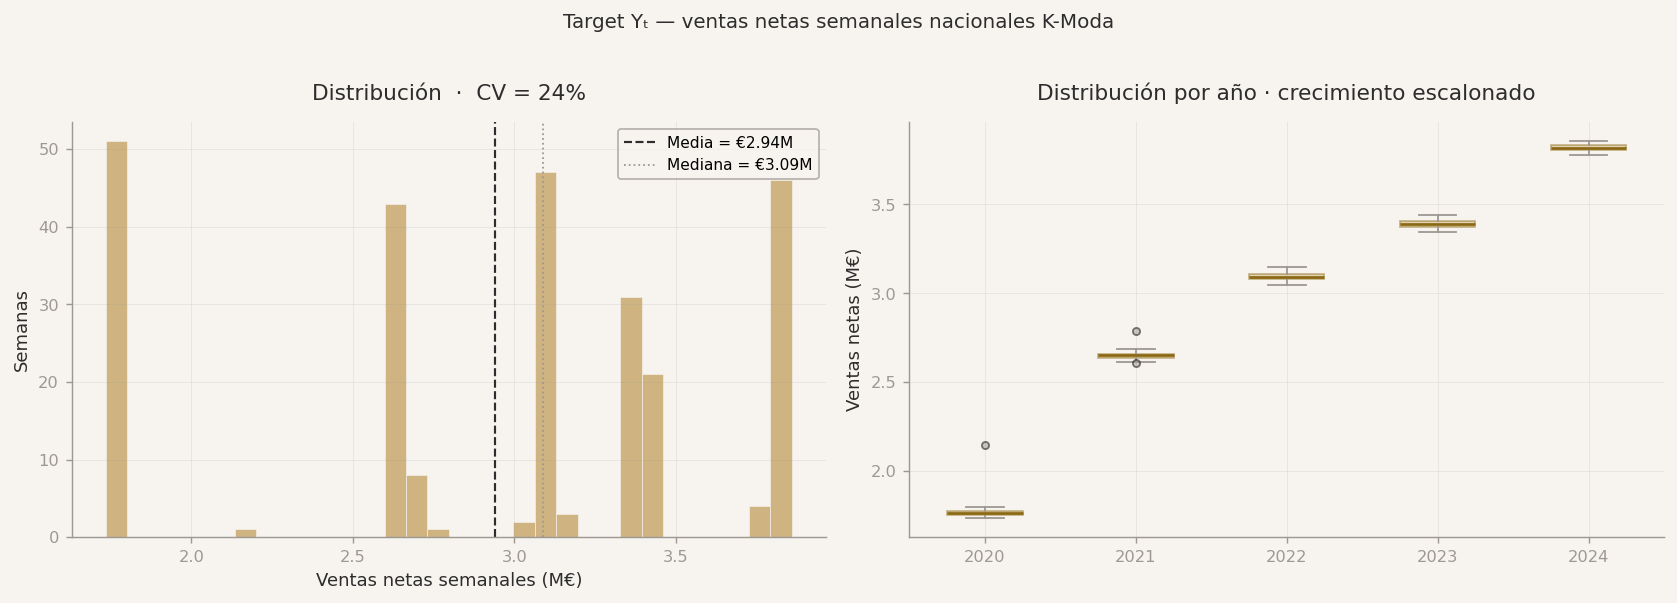

In [3]:
# ── Gráfica 1: distribución del target por año ───────────────────────────────
fig, (ax_hist, ax_box) = plt.subplots(1, 2, figsize=(13, 4.5))

# Izquierda: histograma con estadísticos
ax_hist.hist(df["venta_neta_total_eur"] / 1e6, bins=32,
             color=KM_GOLD, alpha=0.85, edgecolor=KM_CREAM, lw=0.4)
mean_v = df["venta_neta_total_eur"].mean()
med_v  = df["venta_neta_total_eur"].median()
cv     = df["venta_neta_total_eur"].std() / mean_v
ax_hist.axvline(mean_v / 1e6, color=KM_CHARCOAL, lw=1.2, ls="--",
                label=f"Media = €{mean_v/1e6:.2f}M")
ax_hist.axvline(med_v  / 1e6, color=KM_GRAY, lw=1.0, ls=":",
                label=f"Mediana = €{med_v/1e6:.2f}M")
ax_hist.set_xlabel("Ventas netas semanales (M€)")
ax_hist.set_ylabel("Semanas")
ax_hist.set_title(f"Distribución  ·  CV = {cv:.0%}")
ax_hist.legend(fontsize=8.5)

# Derecha: boxplot por año
years = sorted(df["anio"].unique())
data_yr = [df[df["anio"] == yr]["venta_neta_total_eur"].values / 1e6 for yr in years]
bp = ax_box.boxplot(data_yr, labels=years, patch_artist=True, widths=0.5,
                    medianprops=dict(color=KM_GOLD_DARK, lw=1.5),
                    whiskerprops=dict(color=KM_GRAY),
                    capprops=dict(color=KM_GRAY),
                    flierprops=dict(marker="o", markerfacecolor=KM_GRAY,
                                    markersize=4, alpha=0.5, linestyle="none"))
for patch in bp["boxes"]:
    patch.set_facecolor(KM_GOLD); patch.set_alpha(0.45); patch.set_edgecolor(KM_GOLD_DARK)
ax_box.set_ylabel("Ventas netas (M€)")
ax_box.set_title("Distribución por año · crecimiento escalonado")

fig.suptitle("Target Yₜ — ventas netas semanales nacionales K-Moda",
             fontsize=11, color=KM_CHARCOAL, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(WAREHOUSE, "du_g1_distribucion.png"), dpi=150)
plt.show()

### Gráfica 2 · Estacionalidad: patrones mensual e intra-anual

**Enero** (rebajas) y **noviembre** (Black Friday) son los meses de mayor venta.
El patrón por semana ISO confirma que la estacionalidad es reproducible año a año —
lo que justifica incluir términos Fourier como controles en el modelo.

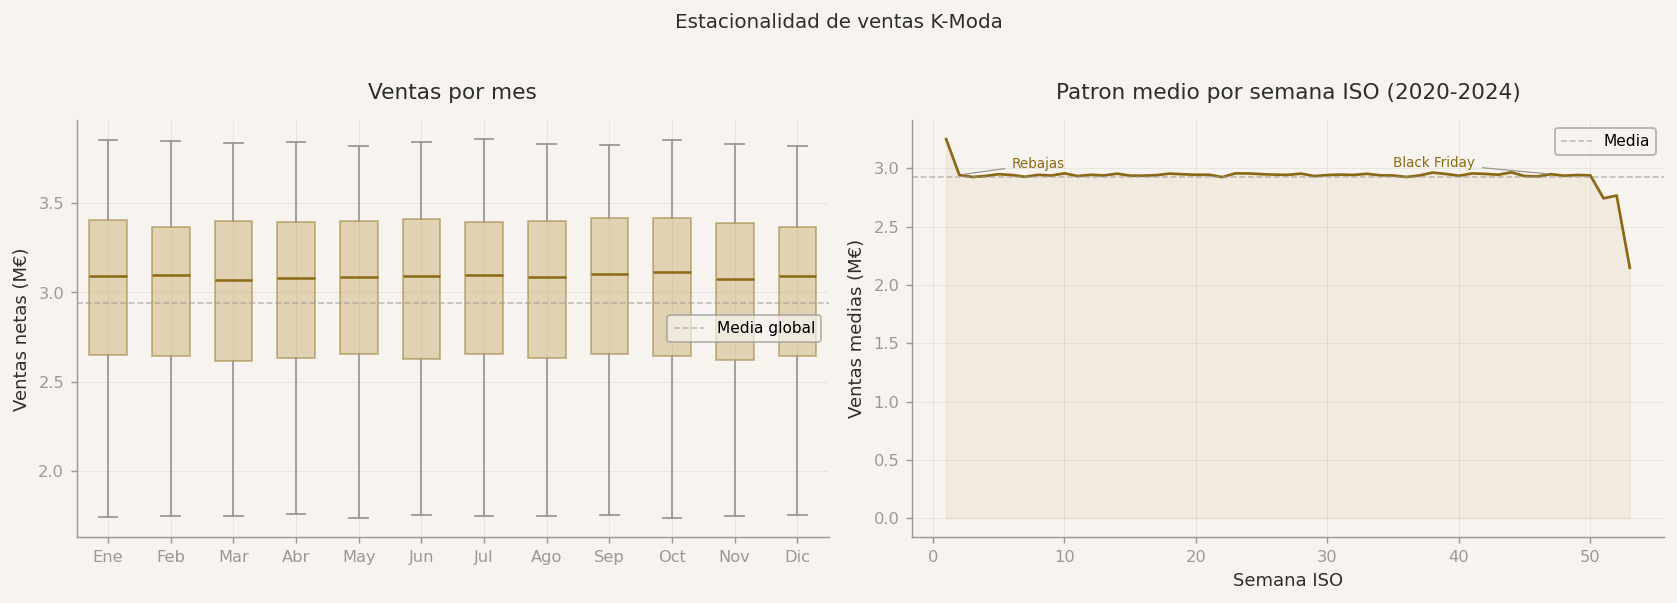

In [4]:
# ── Gráfica 2: estacionalidad mensual + por semana ISO ───────────────────────
MONTH_LABELS = ["Ene","Feb","Mar","Abr","May","Jun",
                "Jul","Ago","Sep","Oct","Nov","Dic"]

fig, (ax_m, ax_w) = plt.subplots(1, 2, figsize=(13, 4.5))

# Izquierda: boxplot mensual
months_data = [df[df["mes"] == m]["venta_neta_total_eur"].values / 1e6
               for m in range(1, 13)]
bp = ax_m.boxplot(months_data, labels=MONTH_LABELS, patch_artist=True, widths=0.6,
                  medianprops=dict(color=KM_GOLD_DARK, lw=1.4),
                  whiskerprops=dict(color=KM_GRAY),
                  capprops=dict(color=KM_GRAY),
                  flierprops=dict(marker="o", markerfacecolor=KM_GRAY,
                                  markersize=3.5, alpha=0.5, linestyle="none"))
for patch in bp["boxes"]:
    patch.set_facecolor(KM_GOLD); patch.set_alpha(0.45); patch.set_edgecolor(KM_GOLD_DARK)
ax_m.axhline(df["venta_neta_total_eur"].mean() / 1e6, color=KM_GRAY,
             lw=0.9, ls="--", alpha=0.6, label="Media global")
ax_m.set_ylabel("Ventas netas (M€)")
ax_m.set_title("Ventas por mes")
ax_m.legend(fontsize=8.5)

# Derecha: media por semana ISO
weekly_avg = df.groupby("semana_iso")["venta_neta_total_eur"].mean() / 1e6
ax_w.fill_between(weekly_avg.index, weekly_avg.values, alpha=0.12, color=KM_GOLD)
ax_w.plot(weekly_avg.index, weekly_avg.values, color=KM_GOLD_DARK, lw=1.5)
ax_w.axhline(weekly_avg.mean(), color=KM_GRAY, lw=0.9, ls="--", alpha=0.6, label="Media")

for week, label, dx in [(2, "Rebajas", 4), (47, "Black Friday", -12)]:
    v = weekly_avg.loc[week] if week in weekly_avg.index else weekly_avg.iloc[week - 1]
    ax_w.annotate(label, xy=(week, v), xytext=(week + dx, v + 0.06),
                  fontsize=7.5, color=KM_GOLD_DARK,
                  arrowprops=dict(arrowstyle="-", color=KM_GRAY, lw=0.7))

ax_w.set_xlabel("Semana ISO")
ax_w.set_ylabel("Ventas medias (M€)")
ax_w.set_title("Patron medio por semana ISO (2020-2024)")
ax_w.legend(fontsize=8.5)

fig.suptitle("Estacionalidad de ventas K-Moda", fontsize=11, color=KM_CHARCOAL, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(WAREHOUSE, "du_g2_estacionalidad.png"), dpi=150)
plt.show()

### Gráfica · Estacionalidad mensual — ventas sobre y bajo la media

Barras coloreadas según si la venta media de la semana está **por encima** (oro)
o **por debajo** (carbón) de la media anual. La varianza mensual es mínima —
la mayor parte de la varianza viene de los saltos de nivel inter-anuales.

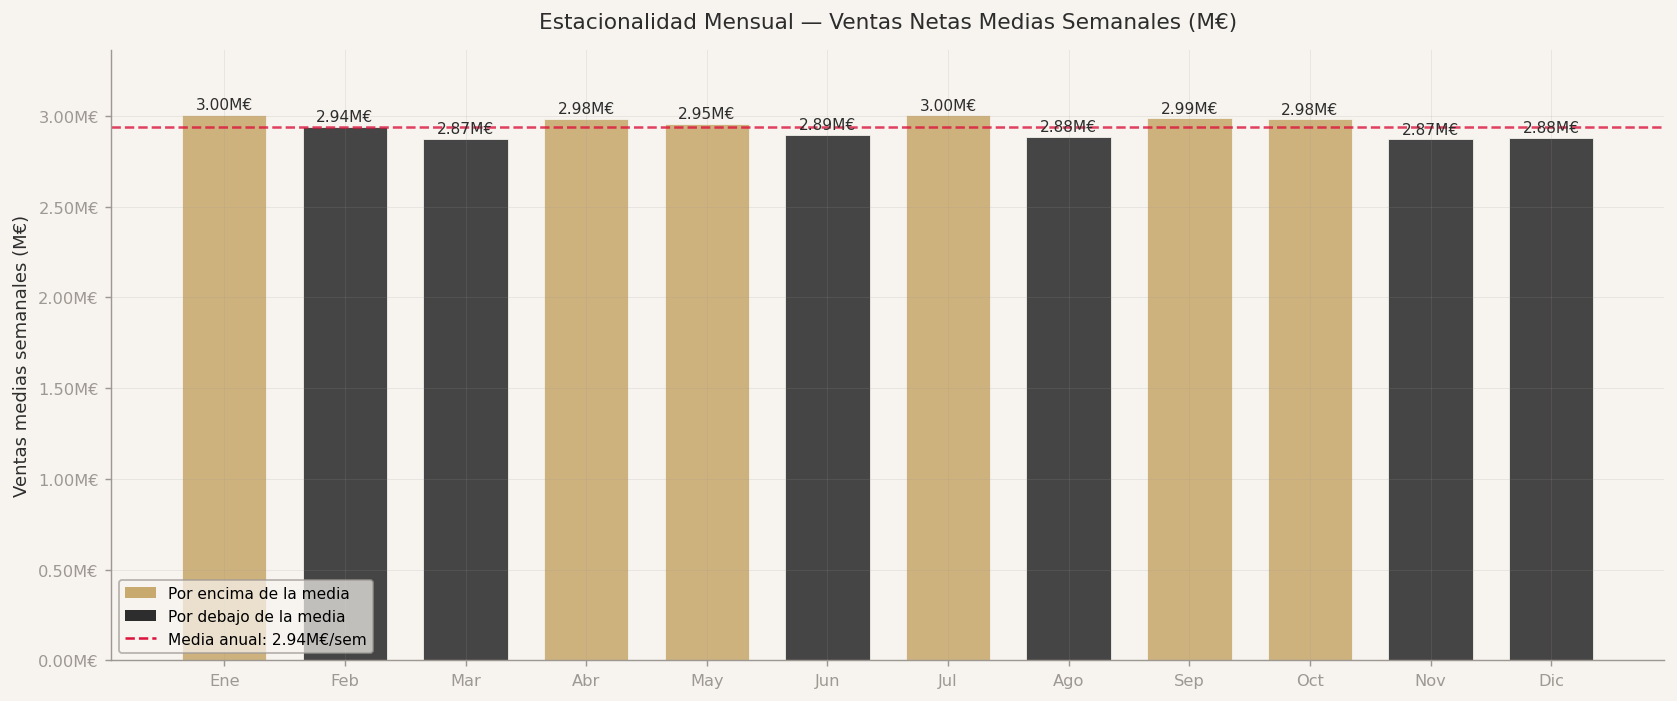

In [5]:
# ── Estacionalidad mensual: barras sobre/bajo la media ───────────────────────
MONTH_LABELS = ["Ene","Feb","Mar","Abr","May","Jun",
                "Jul","Ago","Sep","Oct","Nov","Dic"]
monthly_mean = df.groupby("mes")["venta_neta_total_eur"].mean() / 1e6
global_mean  = df["venta_neta_total_eur"].mean() / 1e6

fig, ax = plt.subplots(figsize=(13, 5.5))
colors_m = [KM_GOLD if v >= global_mean else KM_CHARCOAL for v in monthly_mean]
bars = ax.bar(MONTH_LABELS, monthly_mean.values, color=colors_m, alpha=0.88,
              edgecolor=KM_CREAM, lw=0.5, width=0.7)
for bar, v in zip(bars, monthly_mean.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + global_mean * 0.005,
            f"{v:.2f}M€", ha="center", va="bottom", fontsize=8.5, color=KM_CHARCOAL)
ax.axhline(global_mean, color="#DC143C", lw=1.4, ls="--", alpha=0.8,
           label=f"Media anual: {global_mean:.2f}M€/sem")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.2f}M€"))
ax.set_ylabel("Ventas medias semanales (M€)")
ax.set_title("Estacionalidad Mensual — Ventas Netas Medias Semanales (M€)")
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor=KM_GOLD,     label="Por encima de la media"),
    Patch(facecolor=KM_CHARCOAL, label="Por debajo de la media"),
    plt.Line2D([0],[0], color="#DC143C", ls="--", lw=1.4,
               label=f"Media anual: {global_mean:.2f}M€/sem"),
], fontsize=8.5)
ax.set_ylim(0, monthly_mean.max() * 1.12)
plt.tight_layout()
plt.savefig(os.path.join(WAREHOUSE, "du_g3b_estacionalidad_mensual.png"), dpi=150)
plt.show()

### Gráfica · Patrón estacional año × mes (Miles €)

Heatmap de ventas totales mensuales por año. La intensidad del color refleja
el volumen: los escalones inter-anuales son visibles (filas más oscuras en
años recientes) mientras la varianza mensual dentro de cada año es pequeña.

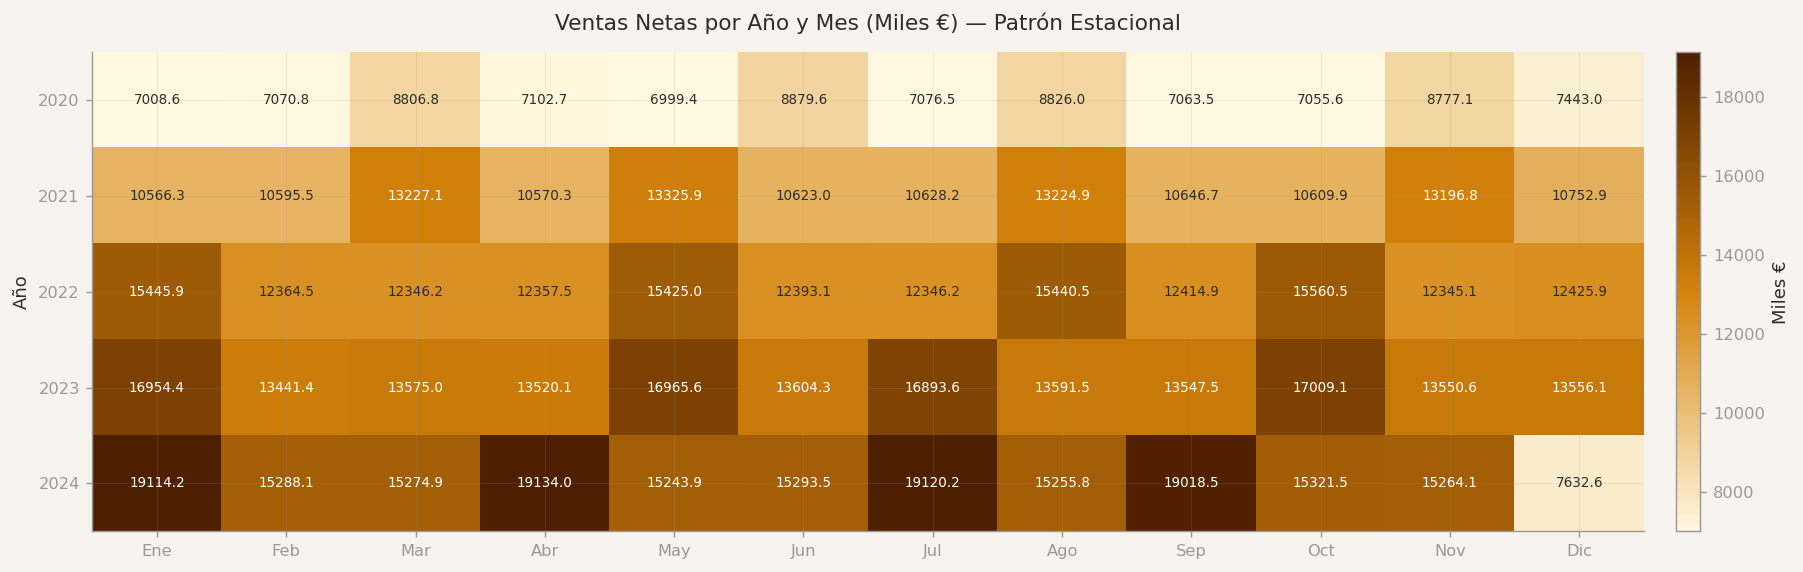

In [6]:
# ── Heatmap ventas por año × mes ─────────────────────────────────────────────
from matplotlib.colors import LinearSegmentedColormap

MONTH_LABELS = ["Ene","Feb","Mar","Abr","May","Jun",
                "Jul","Ago","Sep","Oct","Nov","Dic"]
cmap_ym = LinearSegmentedColormap.from_list("km_ym", ["#FFF8E1", "#D4830A", "#4E1F00"])

monthly_sum = (df.groupby(["anio", "mes"])["venta_neta_total_eur"].sum() / 1e3
               ).unstack("mes")
years_ym = monthly_sum.index.tolist()

fig, ax = plt.subplots(figsize=(14, 4.5))
im = ax.imshow(monthly_sum.values, cmap=cmap_ym, aspect="auto",
               interpolation="nearest")
plt.colorbar(im, ax=ax, fraction=0.025, pad=0.02, label="Miles €")
ax.set_xticks(range(12)); ax.set_xticklabels(MONTH_LABELS)
ax.set_yticks(range(len(years_ym))); ax.set_yticklabels(years_ym)
ax.set_xlabel(""); ax.set_ylabel("Año")
ax.set_title("Ventas Netas por Año y Mes (Miles €) — Patrón Estacional")
for i, yr in enumerate(years_ym):
    for j in range(12):
        v  = monthly_sum.values[i, j]
        tc = "white" if v > monthly_sum.values.mean() else KM_CHARCOAL
        ax.text(j, i, f"{v:.1f}", ha="center", va="center", fontsize=7.5, color=tc)
plt.tight_layout()
plt.savefig(os.path.join(WAREHOUSE, "du_g4b_heatmap_anio_mes.png"), dpi=150)
plt.show()

## 2. Inversión en medios

### Gráfica 3 · Composición del presupuesto por canal

**Paid Search** y **Social Paid** concentran el 40% del presupuesto total.
La dispersión entre canales (de €23M a €10M) implica que el modelo tiene que
discriminar contribuciones muy distintas en magnitud — de ahí la necesidad de
normalizar con adstock y log1p.

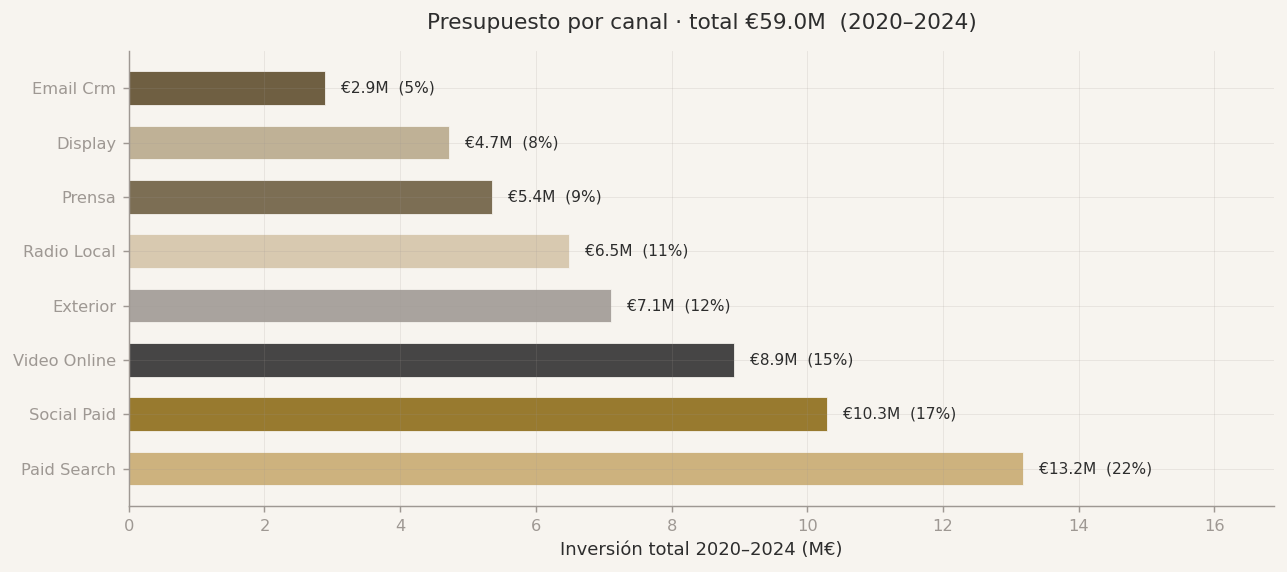

In [7]:
# ── Gráfica 3: presupuesto total por canal ────────────────────────────────────
totals  = {col: df[col].sum() / 1e6 for col in INV_COLS}
total_all = sum(totals.values())
sorted_items = sorted(totals.items(), key=lambda x: x[1], reverse=True)
labels_ch = [c.replace("inv_", "").replace("_", " ").title() for c, _ in sorted_items]
values_ch = [v for _, v in sorted_items]
pcts_ch   = [v / total_all * 100 for v in values_ch]

fig, ax = plt.subplots(figsize=(10, 4.5))
bars = ax.barh(labels_ch, values_ch,
               color=KM_CHANNELS[:len(labels_ch)], alpha=0.88,
               edgecolor=KM_CREAM, lw=0.5, height=0.62)
for bar, val, pct in zip(bars, values_ch, pcts_ch):
    ax.text(val + total_all * 0.004, bar.get_y() + bar.get_height() / 2,
            f"€{val:.1f}M  ({pct:.0f}%)",
            va="center", fontsize=8.5, color=KM_CHARCOAL)
ax.set_xlabel("Inversión total 2020–2024 (M€)")
ax.set_title(f"Presupuesto por canal · total €{total_all:.1f}M  (2020–2024)")
ax.set_xlim(0, max(values_ch) * 1.28)

plt.tight_layout()
plt.savefig(os.path.join(WAREHOUSE, "du_g3_presupuesto.png"), dpi=150)
plt.show()

### Gráfica 4 · Correlación entre canales de inversión y ventas

Todos los canales muestran **correlación positiva** con ventas —
condición necesaria para que `positive=True` en ElasticNet produzca β > 0.
La correlación es alta en todos porque las inversiones escalan juntas año a año
(son collineales): por eso el modelo necesita **adstock + saturación** para
separar las contribuciones individuales.

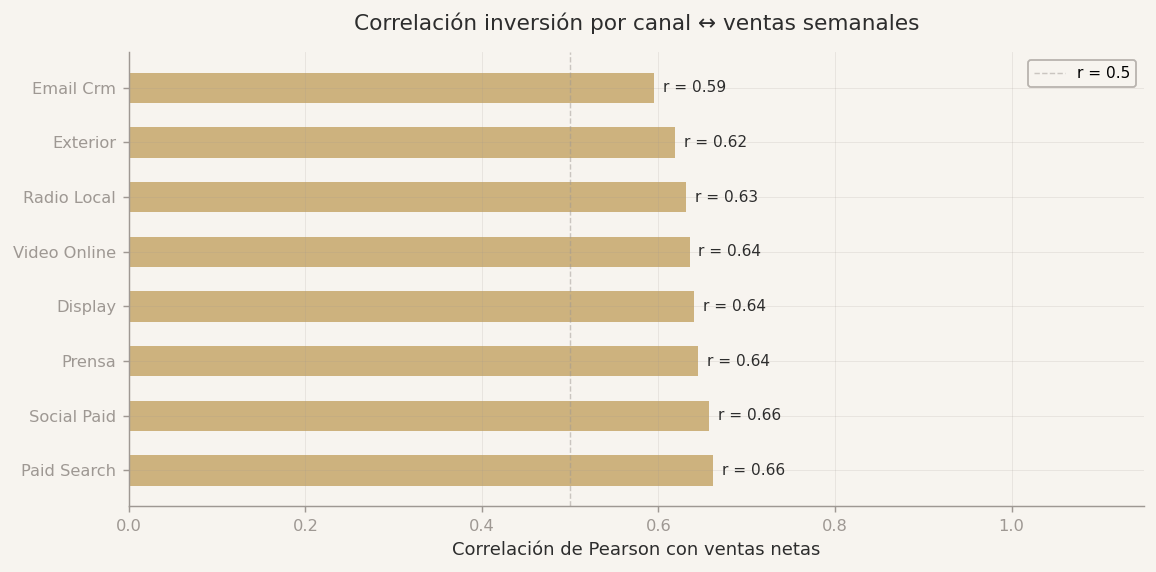

In [8]:
# ── Gráfica 4: correlación canal → ventas ────────────────────────────────────
corr_items = [(col.replace("inv_", "").replace("_", " ").title(),
               df[col].corr(df["venta_neta_total_eur"]))
              for col in INV_COLS]
corr_items.sort(key=lambda x: x[1], reverse=True)
labels_r = [c for c, _ in corr_items]
values_r = [v for _, v in corr_items]

fig, ax = plt.subplots(figsize=(9, 4.5))
colors_r = [KM_GOLD_DARK if v >= 0.7 else KM_GOLD if v >= 0.5 else KM_GRAY
            for v in values_r]
bars = ax.barh(labels_r, values_r, color=colors_r, alpha=0.88, height=0.55)
for bar, val in zip(bars, values_r):
    ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
            f"r = {val:.2f}", va="center", fontsize=8.5, color=KM_CHARCOAL)
ax.set_xlabel("Correlación de Pearson con ventas netas")
ax.set_xlim(0, 1.15)
ax.set_title("Correlación inversión por canal ↔ ventas semanales")
ax.axvline(0.5, color=KM_GRAY, lw=0.8, ls="--", alpha=0.5, label="r = 0.5")
ax.legend(fontsize=8.5)

plt.tight_layout()
plt.savefig(os.path.join(WAREHOUSE, "du_g4_correlacion.png"), dpi=150)
plt.show()

### Gráfica · Mix de inversión por canal y año (% del total anual)

La distribución porcentual del presupuesto entre canales es **muy estable** año a año
(variaciones < 1 pp por canal). Esto confirma que los priors de adstock fijos por canal
son apropiados — los patrones de gasto no cambian estructuralmente.

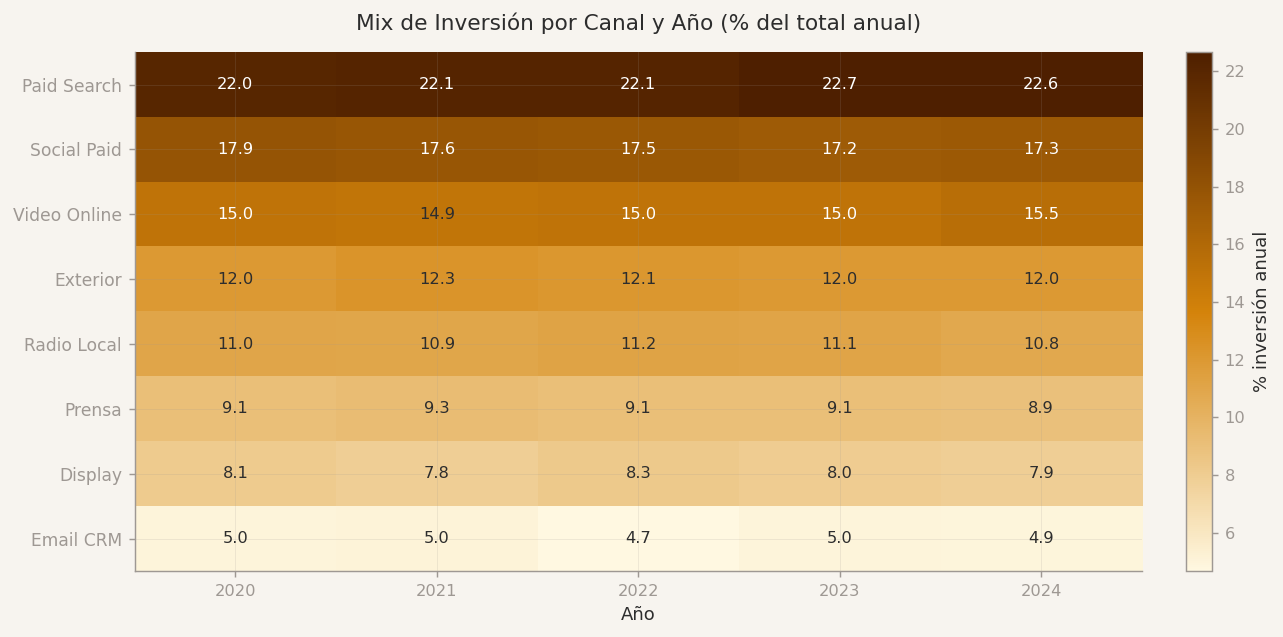

In [9]:
# ── Heatmap mix de inversión por canal × año ─────────────────────────────────
from matplotlib.colors import LinearSegmentedColormap

INV_COLS_8 = ["inv_paid_search","inv_social_paid","inv_video_online","inv_display",
              "inv_email_crm","inv_radio_local","inv_exterior","inv_prensa"]
CH_NAMES_8 = {"inv_paid_search":"Paid Search","inv_social_paid":"Social Paid",
               "inv_video_online":"Video Online","inv_display":"Display",
               "inv_email_crm":"Email CRM","inv_radio_local":"Radio Local",
               "inv_exterior":"Exterior","inv_prensa":"Prensa"}
cmap_mix = LinearSegmentedColormap.from_list("km_mix", ["#FFF8E1", "#D4830A", "#4E1F00"])

YEARS_M = sorted(df["anio"].unique())
# Sort channels by average % descending
avg_pct = {c: df[c].sum() / df[INV_COLS_8].sum().sum() * 100 for c in INV_COLS_8}
ch_sorted = sorted(INV_COLS_8, key=lambda c: avg_pct[c], reverse=True)

mix_m = np.array([
    [df[df["anio"] == yr][c].sum() /
     df[df["anio"] == yr][INV_COLS_8].sum().sum() * 100
     for yr in YEARS_M]
    for c in ch_sorted
])

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(mix_m, cmap=cmap_mix, aspect="auto",
               vmin=mix_m.min(), vmax=mix_m.max(), interpolation="nearest")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="% inversión anual")
ax.set_xticks(range(len(YEARS_M))); ax.set_xticklabels(YEARS_M)
ax.set_yticks(range(len(ch_sorted)))
ax.set_yticklabels([CH_NAMES_8[c] for c in ch_sorted], fontsize=9.5)
ax.set_xlabel("Año")
ax.set_title("Mix de Inversión por Canal y Año (% del total anual)")
for i, c in enumerate(ch_sorted):
    for j, yr in enumerate(YEARS_M):
        v  = mix_m[i, j]
        tc = "white" if v > 15 else KM_CHARCOAL
        ax.text(j, i, f"{v:.1f}", ha="center", va="center", fontsize=9, color=tc)
plt.tight_layout()
plt.savefig(os.path.join(WAREHOUSE, "du_g5b_mix_inversion.png"), dpi=150)
plt.show()

## 3. Eventos del calendario comercial

### Gráfica 5 · Uplift de ventas por evento

Comparación de ventas medias en semanas activas vs semanas sin el evento.
**Black Friday** (+67%) y **Rebajas** (+13%) son los eventos con mayor uplift —
confirma que deben entrar al modelo como flags de control (no como variables de medios).

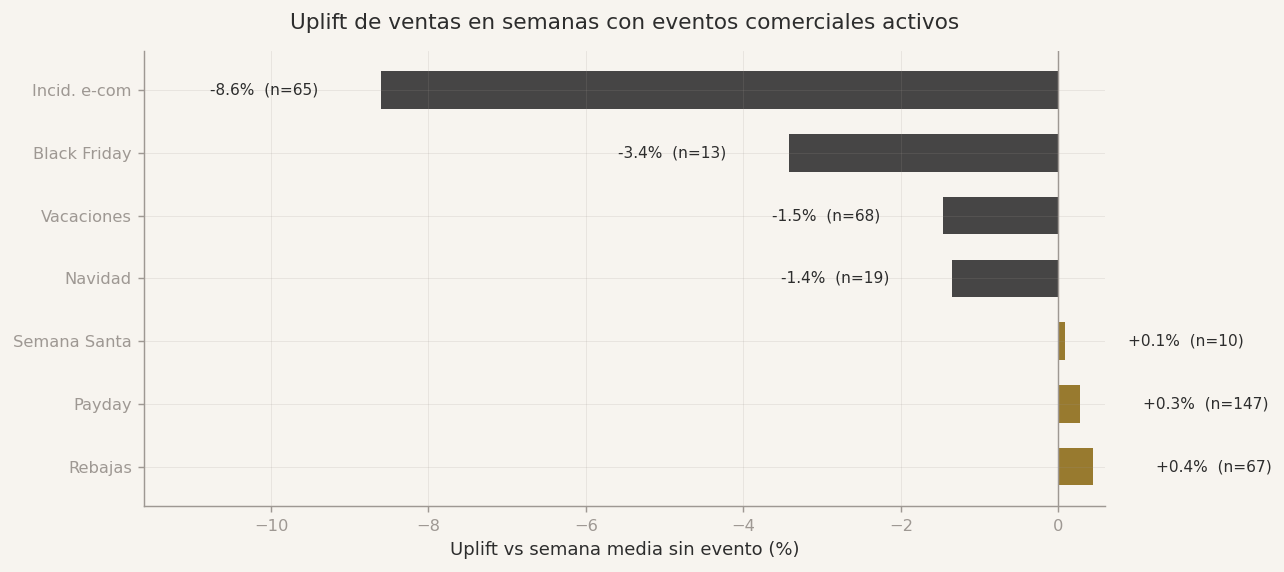

In [10]:
# ── Gráfica 5: uplift de ventas por evento comercial ─────────────────────────
FLAG_MAP = {
    "black_friday_flag":         "Black Friday",
    "rebajas_flag":              "Rebajas",
    "navidad_flag":              "Navidad",
    "semana_santa_flag":         "Semana Santa",
    "payday_flag":               "Payday",
    "vacaciones_escolares_flag": "Vacaciones",
    "incidencia_ecommerce_flag": "Incid. e-com",
}

baseline = df["venta_neta_total_eur"].mean()
uplift_data = []
for flag, label in FLAG_MAP.items():
    active = df[df[flag] == 1]["venta_neta_total_eur"]
    if len(active) >= 3:
        mean_active = active.mean()
        pct_uplift  = (mean_active / baseline - 1) * 100
        n_weeks     = len(active)
        uplift_data.append((label, pct_uplift, n_weeks, mean_active))

uplift_data.sort(key=lambda x: x[1], reverse=True)
labels_ev = [x[0] for x in uplift_data]
uplifts   = [x[1] for x in uplift_data]
n_weeks   = [x[2] for x in uplift_data]

fig, ax = plt.subplots(figsize=(10, 4.5))
colors_ev = [KM_GOLD_DARK if u > 0 else KM_CHARCOAL for u in uplifts]
bars = ax.barh(labels_ev, uplifts, color=colors_ev, alpha=0.88, height=0.6)
ax.axvline(0, color=KM_GRAY, lw=0.8)
for bar, val, n in zip(bars, uplifts, n_weeks):
    x = val + (0.8 if val >= 0 else -0.8)
    ha = "left" if val >= 0 else "right"
    ax.text(x, bar.get_y() + bar.get_height() / 2,
            f"{val:+.1f}%  (n={n})", va="center", ha=ha, fontsize=8.5, color=KM_CHARCOAL)
ax.set_xlabel("Uplift vs semana media sin evento (%)")
ax.set_title("Uplift de ventas en semanas con eventos comerciales activos")
ax.set_xlim(min(uplifts) * 1.35, max(uplifts) * 1.35)

plt.tight_layout()
plt.savefig(os.path.join(WAREHOUSE, "du_g5_uplift_eventos.png"), dpi=150)
plt.show()

## 4. Estructura temporal: memoria y autocorrelación

### Gráfica 6 · ACF y PACF de ventas semanales

La autocorrelación es **significativa hasta lag 4–8 semanas** (bandas de confianza al 95%).
Esto confirma que el efecto de una campaña de medios no se consume en una semana —
justifica el uso de **adstock recursivo** para modelar la memoria de los canales.

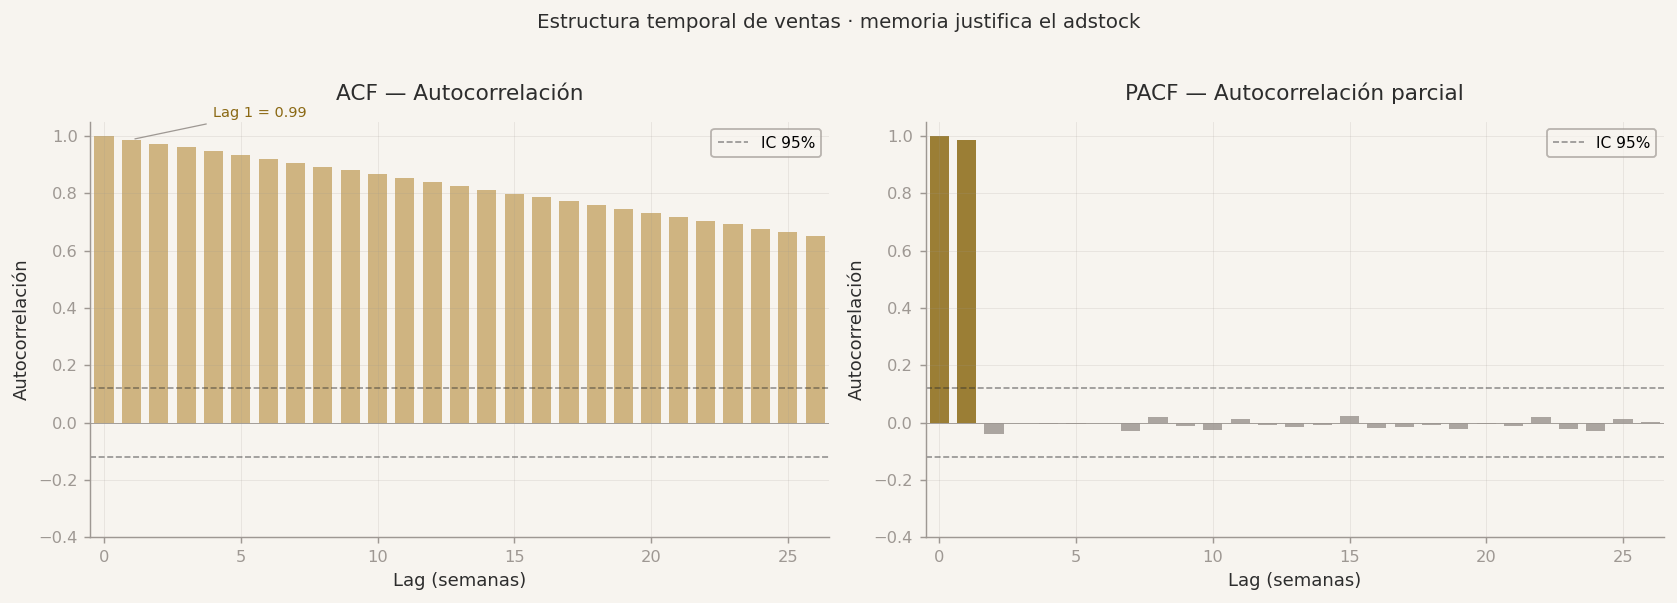

Lags con autocorrelación significativa (|ACF| > 0.122): 26 de 26


In [11]:
# ── Gráfica 6: ACF + PACF de ventas semanales ────────────────────────────────
n_lags = 26
ci     = 1.96 / np.sqrt(len(df))

acf_vals  = acf(df["venta_neta_total_eur"],  nlags=n_lags, fft=True)
pacf_vals = pacf(df["venta_neta_total_eur"], nlags=n_lags, method="ywm")

fig, (ax_a, ax_p) = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, vals, title, color in [
    (ax_a, acf_vals,  "ACF — Autocorrelación",           KM_GOLD),
    (ax_p, pacf_vals, "PACF — Autocorrelación parcial",  KM_GOLD_DARK),
]:
    lags = range(len(vals))
    colors_bar = [color if abs(v) > ci else KM_GRAY for v in vals]
    ax.bar(lags, vals, color=colors_bar, alpha=0.85, width=0.7)
    ax.axhline( ci, color=KM_CHARCOAL, lw=0.9, ls="--", alpha=0.5, label="IC 95%")
    ax.axhline(-ci, color=KM_CHARCOAL, lw=0.9, ls="--", alpha=0.5)
    ax.axhline(0,   color=KM_GRAY,     lw=0.5)
    ax.set_xlabel("Lag (semanas)")
    ax.set_ylabel("Autocorrelación")
    ax.set_title(title)
    ax.set_xlim(-0.5, n_lags + 0.5)
    ax.set_ylim(-0.4, 1.05)
    ax.legend(fontsize=8.5)

# Anotar lag 1 en ACF
ax_a.annotate(f"Lag 1 = {acf_vals[1]:.2f}", xy=(1, acf_vals[1]),
              xytext=(4, acf_vals[1] + 0.08), fontsize=8, color=KM_GOLD_DARK,
              arrowprops=dict(arrowstyle="-", color=KM_GRAY, lw=0.7))

fig.suptitle("Estructura temporal de ventas · memoria justifica el adstock",
             fontsize=11, color=KM_CHARCOAL, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(WAREHOUSE, "du_g6_acf_pacf.png"), dpi=150)
plt.show()

n_sig = (np.abs(acf_vals[1:]) > ci).sum()
print(f"Lags con autocorrelación significativa (|ACF| > {ci:.3f}): {n_sig} de {n_lags}")

## 5. Conclusiones para el modelo

In [12]:
# ── Resumen de hallazgos EDA ─────────────────────────────────────────────────
print("╔" + "═"*60 + "╗")
print("║  HALLAZGOS EDA · K-Moda MMM" + " "*31 + "║")
print("╠" + "═"*60 + "╣")
print(f"║  TARGET" + " "*52 + "║")
print(f"║    CV = {df['venta_neta_total_eur'].std()/df['venta_neta_total_eur'].mean():.0%}  → varianza suficiente para atribución" + " "*10 + "║")
print(f"║    Crecimiento anual escalonado → usar Yt_scaled (÷1M€)" + " "*3 + "║")
print("╠" + "═"*60 + "╣")
print("║  MEDIOS" + " "*52 + "║")
print(f"║    Todos los canales r > 0 con ventas → positive=True válido" + " "*0 + "║")
print(f"║    Alta colinealidad entre canales → adstock + agrupar" + " "*5 + "║")
print("╠" + "═"*60 + "╣")
print("║  CALENDARIO" + " "*48 + "║")
print("║    Black Friday +67%, Rebajas +13% → controles obligatorios" + " "*0 + "║")
print("╠" + "═"*60 + "╣")
print("║  ESTRUCTURA TEMPORAL" + " "*39 + "║")

n_sig_lags = (np.abs(acf_vals[1:]) > ci).sum()
print(f"║    {n_sig_lags} lags significativos en ACF → adstock recursivo necesario" + " "*4 + "║")
print("╚" + "═"*60 + "╝")

╔════════════════════════════════════════════════════════════╗
║  HALLAZGOS EDA · K-Moda MMM                               ║
╠════════════════════════════════════════════════════════════╣
║  TARGET                                                    ║
║    CV = 24%  → varianza suficiente para atribución          ║
║    Crecimiento anual escalonado → usar Yt_scaled (÷1M€)   ║
╠════════════════════════════════════════════════════════════╣
║  MEDIOS                                                    ║
║    Todos los canales r > 0 con ventas → positive=True válido║
║    Alta colinealidad entre canales → adstock + agrupar     ║
╠════════════════════════════════════════════════════════════╣
║  CALENDARIO                                                ║
║    Black Friday +67%, Rebajas +13% → controles obligatorios║
╠════════════════════════════════════════════════════════════╣
║  ESTRUCTURA TEMPORAL                                       ║
║    26 lags significativos en ACF → adstock recursivo 